
Student Name: Swarup Patil  
U20220085  
swarup_U20220085

# Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from rlcmab_sampler import sampler


# Load Datasets

In [2]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [3]:
# Data Preprocessing
# Handle missing values and encode categorical features

# Check for missing values
print("Missing values in news_df:")
print(news_df.isnull().sum())
print("\nMissing values in train_users:")
print(train_users.isnull().sum())
print("\nMissing values in test_users:")
print(test_users.isnull().sum())

# Handle missing values in train_users
train_users_clean = train_users.copy()
test_users_clean = test_users.copy()

# Fill missing numeric values with median
numeric_cols = train_users_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    median_val = train_users_clean[col].median()
    train_users_clean[col].fillna(median_val, inplace=True)
    test_users_clean[col].fillna(median_val, inplace=True)

# Encode categorical features
le = LabelEncoder()

# Encode subscriber column (True/False -> 1/0)
if 'subscriber' in train_users_clean.columns:
    train_users_clean['subscriber'] = train_users_clean['subscriber'].astype(int)
    test_users_clean['subscriber'] = test_users_clean['subscriber'].astype(int)

# Encode region_code - handle unseen labels
if 'region_code' in train_users_clean.columns:
    le_region = LabelEncoder()
    # Fit on combined data to handle all possible values
    all_regions = pd.concat([train_users_clean['region_code'], test_users_clean['region_code']]).astype(str).unique()
    le_region.fit(all_regions)
    train_users_clean['region_code'] = le_region.transform(train_users_clean['region_code'].astype(str))
    test_users_clean['region_code'] = le_region.transform(test_users_clean['region_code'].astype(str))

# Encode browser_version - handle unseen labels
if 'browser_version' in train_users_clean.columns:
    le_browser = LabelEncoder()
    # Fit on combined data to handle all possible values
    all_browsers = pd.concat([train_users_clean['browser_version'], test_users_clean['browser_version']]).astype(str).unique()
    le_browser.fit(all_browsers)
    train_users_clean['browser_version'] = le_browser.transform(train_users_clean['browser_version'].astype(str))
    test_users_clean['browser_version'] = le_browser.transform(test_users_clean['browser_version'].astype(str))

# Encode label column for users (user_1, user_2, user_3 -> 0, 1, 2)
le_label = LabelEncoder()
train_users_clean['label_encoded'] = le_label.fit_transform(train_users_clean['label'])

print("\nData preprocessing completed!")
print(f"Train users shape: {train_users_clean.shape}")
print(f"Test users shape: {test_users_clean.shape}")
print(f"\nLabel distribution in training data:")
print(train_users_clean['label'].value_counts())

Missing values in news_df:
link                     0
headline                 6
category                 0
short_description    19712
authors              37418
date                     0
dtype: int64

Missing values in train_users:
user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score               

/var/folders/6h/27vy663s43zbdtt1j5r89ccr0000gn/T/ipykernel_19797/4135226214.py:20: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_users_clean[col].fillna(median_val, inplace=True)
/var/folders/6h/27vy663s43zbdtt1j5r89ccr0000gn/T/ipykernel_19797/4135226214.py:21: ChainedAssignmentError: A value is being set on a copy of a DataFra

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [4]:
# User Classification Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Prepare features and labels
feature_cols = [col for col in train_users_clean.columns if col not in ['user_id', 'label', 'label_encoded']]
X = train_users_clean[feature_cols]
y = train_users_clean['label_encoded']

# Split into training and validation sets (80-20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train a Random Forest Classifier
user_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
user_classifier.fit(X_train, y_train)

# Evaluate on validation set
y_pred = user_classifier.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=le_label.classes_))

# Predict user categories for test users
X_test = test_users_clean[feature_cols]
test_users_clean['predicted_label_encoded'] = user_classifier.predict(X_test)
test_users_clean['predicted_label'] = le_label.inverse_transform(test_users_clean['predicted_label_encoded'])

print(f"\nTest users predictions distribution:")
print(test_users_clean['predicted_label'].value_counts())

Validation Accuracy: 0.9050

Classification Report:
              precision    recall  f1-score   support

      user_1       0.89      0.87      0.88       142
      user_2       0.99      0.89      0.94       142
      user_3       0.84      0.97      0.90       116

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400


Test users predictions distribution:
predicted_label
user_2    694
user_1    674
user_3    632
Name: count, dtype: int64


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [5]:
# Initialize Reward Sampler
# Roll number: U20220085 -> 85
ROLL_NUMBER = 85

reward_sampler = sampler(ROLL_NUMBER)
print(f"Sampler initialized with roll number: {ROLL_NUMBER}")

# Define arm mapping
# Arms 0-3: Entertainment, Education, Tech, Crime for User1 (user_1)
# Arms 4-7: Entertainment, Education, Tech, Crime for User2 (user_2)  
# Arms 8-11: Entertainment, Education, Tech, Crime for User3 (user_3)

categories = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
user_contexts = ['user_1', 'user_2', 'user_3']

def get_arm_index(user_context, news_category):
    """
    Convert (user_context, news_category) to arm index j
    """
    user_idx = user_contexts.index(user_context)
    cat_idx = categories.index(news_category.upper())
    return user_idx * 4 + cat_idx

def get_context_category_from_arm(arm_idx):
    """
    Convert arm index j to (user_context, news_category)
    """
    user_idx = arm_idx // 4
    cat_idx = arm_idx % 4
    return user_contexts[user_idx], categories[cat_idx]

# Test the arm mapping
print("\nArm Mapping Examples:")
for i in range(12):
    context, category = get_context_category_from_arm(i)
    print(f"Arm {i}: {category}, {context}")
    
# Verify reverse mapping
print("\nVerifying reverse mapping:")
print(f"user_1, ENTERTAINMENT -> Arm {get_arm_index('user_1', 'ENTERTAINMENT')}")
print(f"user_2, TECH -> Arm {get_arm_index('user_2', 'TECH')}")
print(f"user_3, CRIME -> Arm {get_arm_index('user_3', 'CRIME')}")

Sampler initialized with roll number: 85

Arm Mapping Examples:
Arm 0: ENTERTAINMENT, user_1
Arm 1: EDUCATION, user_1
Arm 2: TECH, user_1
Arm 3: CRIME, user_1
Arm 4: ENTERTAINMENT, user_2
Arm 5: EDUCATION, user_2
Arm 6: TECH, user_2
Arm 7: CRIME, user_2
Arm 8: ENTERTAINMENT, user_3
Arm 9: EDUCATION, user_3
Arm 10: TECH, user_3
Arm 11: CRIME, user_3

Verifying reverse mapping:
user_1, ENTERTAINMENT -> Arm 0
user_2, TECH -> Arm 6
user_3, CRIME -> Arm 11


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [6]:
# Epsilon-Greedy Contextual Bandit

class EpsilonGreedyContextualBandit:
    def __init__(self, n_arms, epsilon, sampler):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.sampler = sampler
        
        # Separate Q-values for each context (3 contexts, 4 arms each)
        self.Q = np.zeros((3, 4))  # 3 user contexts x 4 news categories
        self.N = np.zeros((3, 4))  # Count of times each arm was pulled in each context
        
    def select_arm(self, context_idx):
        """
        Select an arm using epsilon-greedy strategy for the given context
        context_idx: 0 (user_1), 1 (user_2), or 2 (user_3)
        """
        if np.random.random() < self.epsilon:
            # Explore: choose random arm (category)
            arm = np.random.randint(0, 4)
        else:
            # Exploit: choose best arm for this context
            arm = np.argmax(self.Q[context_idx])
        
        # Convert to global arm index
        global_arm = context_idx * 4 + arm
        return global_arm, arm
    
    def update(self, context_idx, arm, reward):
        """
        Update Q-values and counts
        """
        self.N[context_idx, arm] += 1
        # Incremental update of Q-value
        self.Q[context_idx, arm] += (reward - self.Q[context_idx, arm]) / self.N[context_idx, arm]
    
    def get_reward(self, global_arm):
        """
        Get reward from sampler for the selected arm
        """
        return self.sampler.sample(global_arm)

print("Epsilon-Greedy Contextual Bandit class defined!")

Epsilon-Greedy Contextual Bandit class defined!


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [7]:
# Upper Confidence Bound (UCB) Contextual Bandit

class UCBContextualBandit:
    def __init__(self, n_arms, c, sampler):
        self.n_arms = n_arms
        self.c = c  # Exploration parameter
        self.sampler = sampler
        
        # Separate Q-values for each context (3 contexts, 4 arms each)
        self.Q = np.zeros((3, 4))
        self.N = np.zeros((3, 4))
        self.t = 0  # Total time steps
        
    def select_arm(self, context_idx):
        """
        Select an arm using UCB strategy for the given context
        """
        self.t += 1
        
        # Initialize: pull each arm once
        if self.t <= 4:
            arm = (self.t - 1) % 4
            global_arm = context_idx * 4 + arm
            return global_arm, arm
        
        # UCB selection
        ucb_values = np.zeros(4)
        for arm in range(4):
            if self.N[context_idx, arm] == 0:
                ucb_values[arm] = float('inf')
            else:
                exploration_bonus = self.c * np.sqrt(np.log(self.t) / self.N[context_idx, arm])
                ucb_values[arm] = self.Q[context_idx, arm] + exploration_bonus
        
        arm = np.argmax(ucb_values)
        global_arm = context_idx * 4 + arm
        return global_arm, arm
    
    def update(self, context_idx, arm, reward):
        """
        Update Q-values and counts
        """
        self.N[context_idx, arm] += 1
        self.Q[context_idx, arm] += (reward - self.Q[context_idx, arm]) / self.N[context_idx, arm]
    
    def get_reward(self, global_arm):
        """
        Get reward from sampler for the selected arm
        """
        return self.sampler.sample(global_arm)

print("UCB Contextual Bandit class defined!")

UCB Contextual Bandit class defined!


## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [8]:
# SoftMax Contextual Bandit

class SoftMaxContextualBandit:
    def __init__(self, n_arms, tau, sampler):
        self.n_arms = n_arms
        self.tau = tau  # Temperature parameter
        self.sampler = sampler
        
        # Separate Q-values for each context (3 contexts, 4 arms each)
        self.Q = np.zeros((3, 4))
        self.N = np.zeros((3, 4))
        
    def select_arm(self, context_idx):
        """
        Select an arm using SoftMax (Boltzmann) strategy for the given context
        """
        # Compute softmax probabilities
        exp_values = np.exp(self.Q[context_idx] / self.tau)
        probabilities = exp_values / np.sum(exp_values)
        
        # Sample arm based on probabilities
        arm = np.random.choice(4, p=probabilities)
        global_arm = context_idx * 4 + arm
        return global_arm, arm
    
    def update(self, context_idx, arm, reward):
        """
        Update Q-values and counts
        """
        self.N[context_idx, arm] += 1
        self.Q[context_idx, arm] += (reward - self.Q[context_idx, arm]) / self.N[context_idx, arm]
    
    def get_reward(self, global_arm):
        """
        Get reward from sampler for the selected arm
        """
        return self.sampler.sample(global_arm)

print("SoftMax Contextual Bandit class defined!")

SoftMax Contextual Bandit class defined!


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [9]:
# RL Simulation - Run Bandit Algorithms

def run_simulation(bandit, T, train_users_clean):
    """
    Run bandit simulation for T time steps
    Returns: rewards history, cumulative rewards per context
    """
    rewards_history = []
    context_rewards = {0: [], 1: [], 2: []}  # Rewards per context
    
    for t in range(T):
        # Sample a random user from training data
        user_idx = np.random.randint(0, len(train_users_clean))
        context = train_users_clean.iloc[user_idx]['label_encoded']
        
        # Select arm using bandit policy
        global_arm, local_arm = bandit.select_arm(context)
        
        # Get reward from sampler
        reward = bandit.get_reward(global_arm)
        
        # Update bandit
        bandit.update(context, local_arm, reward)
        
        # Record rewards
        rewards_history.append(reward)
        context_rewards[context].append(reward)
    
    return rewards_history, context_rewards

# Simulation parameters
T = 10000  # Time horizon
epsilon_values = [0.01, 0.1, 0.3]  # For Epsilon-Greedy
c_values = [0.5, 1.0, 2.0]  # For UCB
tau = 1.0  # For SoftMax

print(f"Running simulations for T={T} steps...")
print(f"Testing Epsilon-Greedy with ε = {epsilon_values}")
print(f"Testing UCB with C = {c_values}")
print(f"Testing SoftMax with τ = {tau}")

Running simulations for T=10000 steps...
Testing Epsilon-Greedy with ε = [0.01, 0.1, 0.3]
Testing UCB with C = [0.5, 1.0, 2.0]
Testing SoftMax with τ = 1.0


In [10]:
# Run Epsilon-Greedy simulations
print("\n=== Running Epsilon-Greedy Simulations ===")
eg_results = {}

for eps in epsilon_values:
    print(f"\nRunning Epsilon-Greedy with ε={eps}...")
    eg_bandit = EpsilonGreedyContextualBandit(n_arms=12, epsilon=eps, sampler=reward_sampler)
    rewards, context_rewards = run_simulation(eg_bandit, T, train_users_clean)
    eg_results[eps] = {
        'rewards': rewards,
        'context_rewards': context_rewards,
        'Q': eg_bandit.Q.copy(),
        'N': eg_bandit.N.copy()
    }
    avg_reward = np.mean(rewards)
    print(f"  Average Reward: {avg_reward:.4f}")

print("\nEpsilon-Greedy simulations completed!")


=== Running Epsilon-Greedy Simulations ===

Running Epsilon-Greedy with ε=0.01...
  Average Reward: 6.3740

Running Epsilon-Greedy with ε=0.1...
  Average Reward: 5.9649

Running Epsilon-Greedy with ε=0.3...
  Average Reward: 4.7228

Epsilon-Greedy simulations completed!


In [11]:
# Run UCB simulations
print("\n=== Running UCB Simulations ===")
ucb_results = {}

for c in c_values:
    print(f"\nRunning UCB with C={c}...")
    ucb_bandit = UCBContextualBandit(n_arms=12, c=c, sampler=reward_sampler)
    rewards, context_rewards = run_simulation(ucb_bandit, T, train_users_clean)
    ucb_results[c] = {
        'rewards': rewards,
        'context_rewards': context_rewards,
        'Q': ucb_bandit.Q.copy(),
        'N': ucb_bandit.N.copy()
    }
    avg_reward = np.mean(rewards)
    print(f"  Average Reward: {avg_reward:.4f}")

print("\nUCB simulations completed!")


=== Running UCB Simulations ===

Running UCB with C=0.5...
  Average Reward: 6.7918

Running UCB with C=1.0...
  Average Reward: 6.7506

Running UCB with C=2.0...
  Average Reward: 6.7939

UCB simulations completed!


In [12]:
# Run SoftMax simulation
print("\n=== Running SoftMax Simulation ===")
print(f"\nRunning SoftMax with τ={tau}...")
sm_bandit = SoftMaxContextualBandit(n_arms=12, tau=tau, sampler=reward_sampler)
sm_rewards, sm_context_rewards = run_simulation(sm_bandit, T, train_users_clean)
sm_results = {
    'rewards': sm_rewards,
    'context_rewards': sm_context_rewards,
    'Q': sm_bandit.Q.copy(),
    'N': sm_bandit.N.copy()
}
avg_reward = np.mean(sm_rewards)
print(f"  Average Reward: {avg_reward:.4f}")

print("\nSoftMax simulation completed!")
print("\n" + "="*50)
print("All simulations completed successfully!")
print("="*50)


=== Running SoftMax Simulation ===

Running SoftMax with τ=1.0...
  Average Reward: 6.7551

SoftMax simulation completed!

All simulations completed successfully!


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


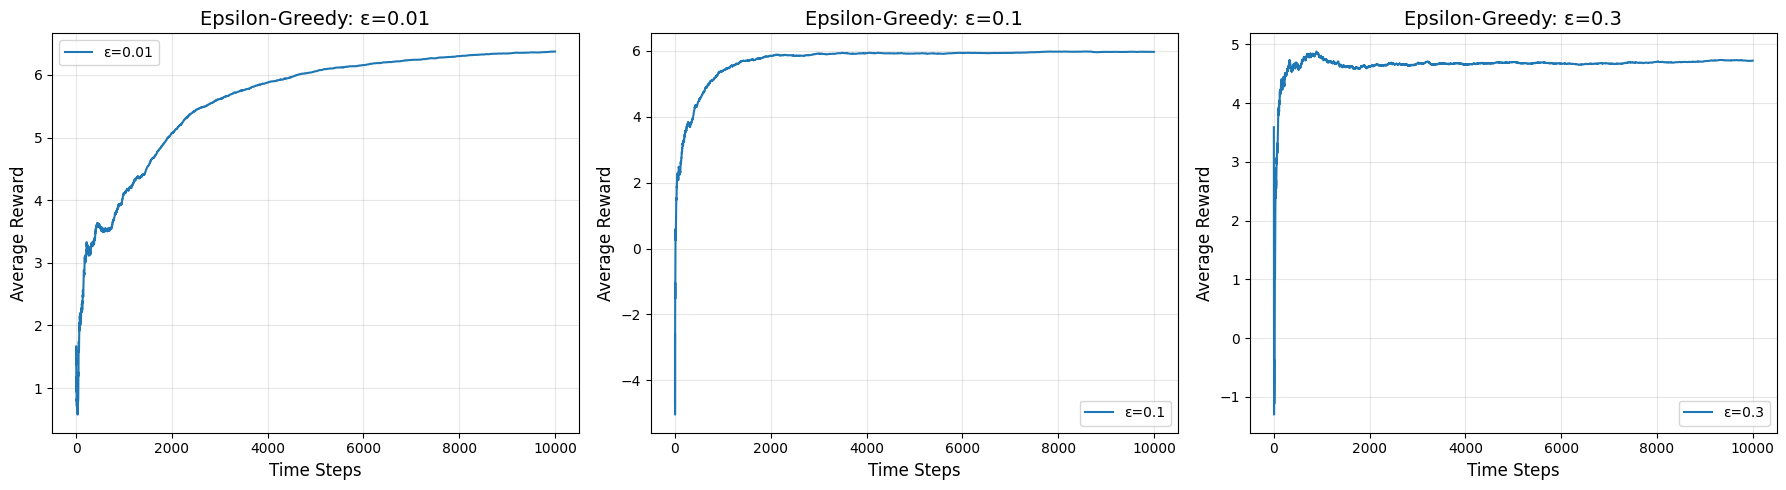

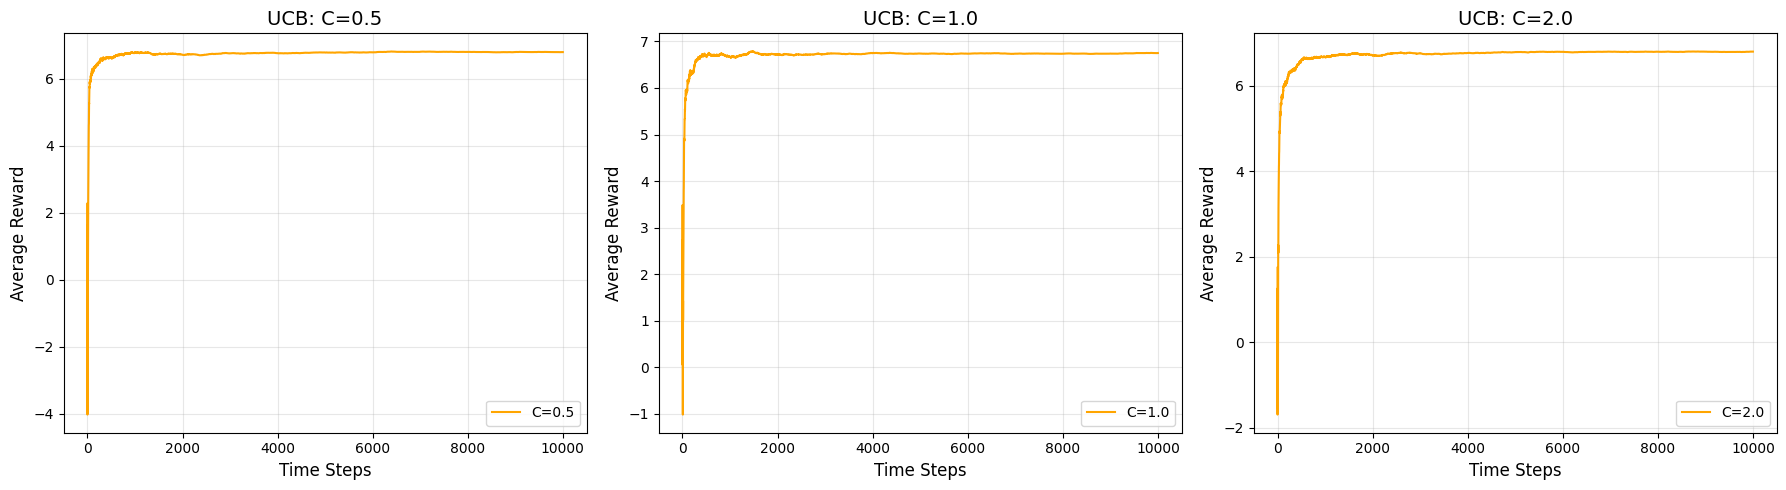

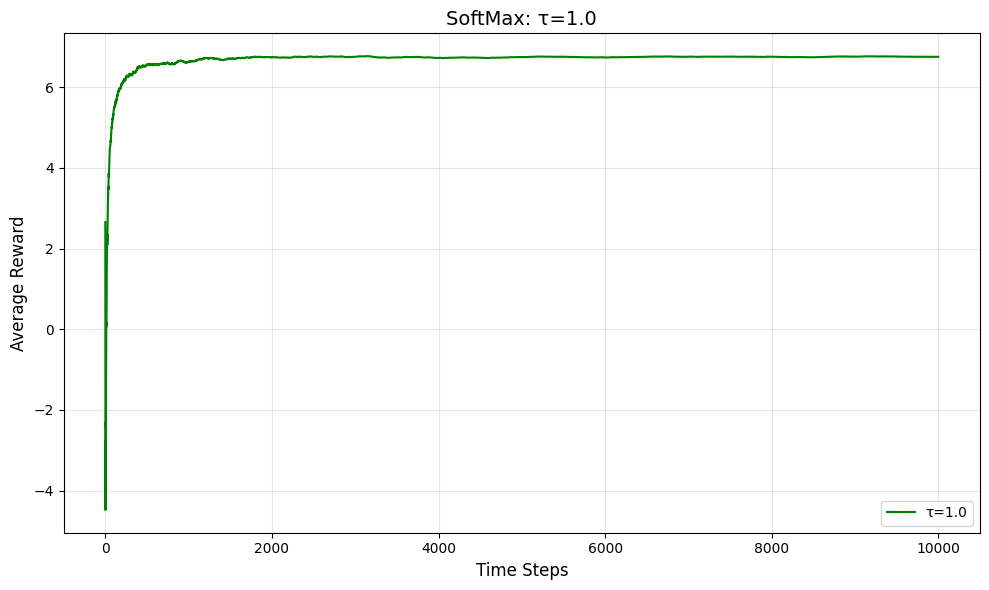

In [13]:
# Results and Analysis - Plot Average Reward vs Time

def compute_cumulative_average(rewards):
    """Compute cumulative average reward over time"""
    cumulative_sum = np.cumsum(rewards)
    time_steps = np.arange(1, len(rewards) + 1)
    return cumulative_sum / time_steps

# Plot 1: Epsilon-Greedy - Average Reward vs Time for different epsilon values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, eps in enumerate(epsilon_values):
    avg_rewards = compute_cumulative_average(eg_results[eps]['rewards'])
    axes[idx].plot(avg_rewards, label=f'ε={eps}')
    axes[idx].set_xlabel('Time Steps', fontsize=12)
    axes[idx].set_ylabel('Average Reward', fontsize=12)
    axes[idx].set_title(f'Epsilon-Greedy: ε={eps}', fontsize=14)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: UCB - Average Reward vs Time for different C values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, c in enumerate(c_values):
    avg_rewards = compute_cumulative_average(ucb_results[c]['rewards'])
    axes[idx].plot(avg_rewards, label=f'C={c}', color='orange')
    axes[idx].set_xlabel('Time Steps', fontsize=12)
    axes[idx].set_ylabel('Average Reward', fontsize=12)
    axes[idx].set_title(f'UCB: C={c}', fontsize=14)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 3: SoftMax - Average Reward vs Time
fig, ax = plt.subplots(figsize=(10, 6))
avg_rewards = compute_cumulative_average(sm_results['rewards'])
ax.plot(avg_rewards, label=f'τ={tau}', color='green')
ax.set_xlabel('Time Steps', fontsize=12)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title(f'SoftMax: τ={tau}', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

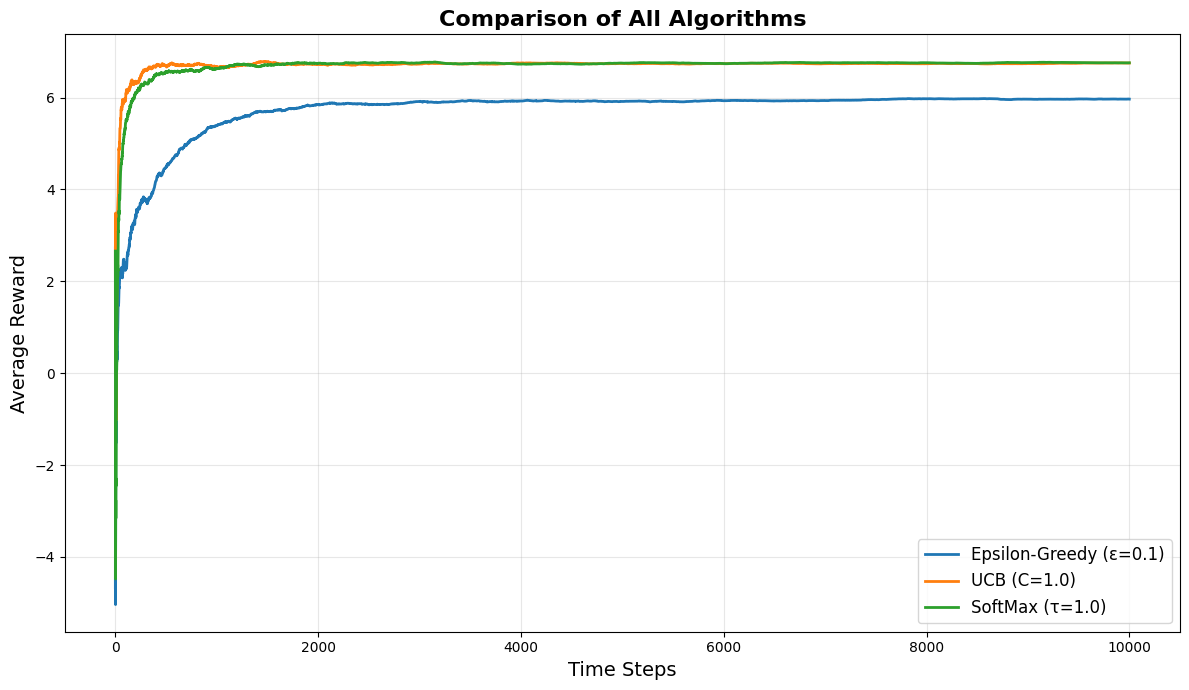

In [14]:
# Comparison of All Algorithms
fig, ax = plt.subplots(figsize=(12, 7))

# Plot best performing hyperparameter for each algorithm
best_eps = 0.1  # Choose the best performing epsilon
best_c = 1.0    # Choose the best performing C

avg_eg = compute_cumulative_average(eg_results[best_eps]['rewards'])
avg_ucb = compute_cumulative_average(ucb_results[best_c]['rewards'])
avg_sm = compute_cumulative_average(sm_results['rewards'])

ax.plot(avg_eg, label=f'Epsilon-Greedy (ε={best_eps})', linewidth=2)
ax.plot(avg_ucb, label=f'UCB (C={best_c})', linewidth=2)
ax.plot(avg_sm, label=f'SoftMax (τ={tau})', linewidth=2)

ax.set_xlabel('Time Steps', fontsize=14)
ax.set_ylabel('Average Reward', fontsize=14)
ax.set_title('Comparison of All Algorithms', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

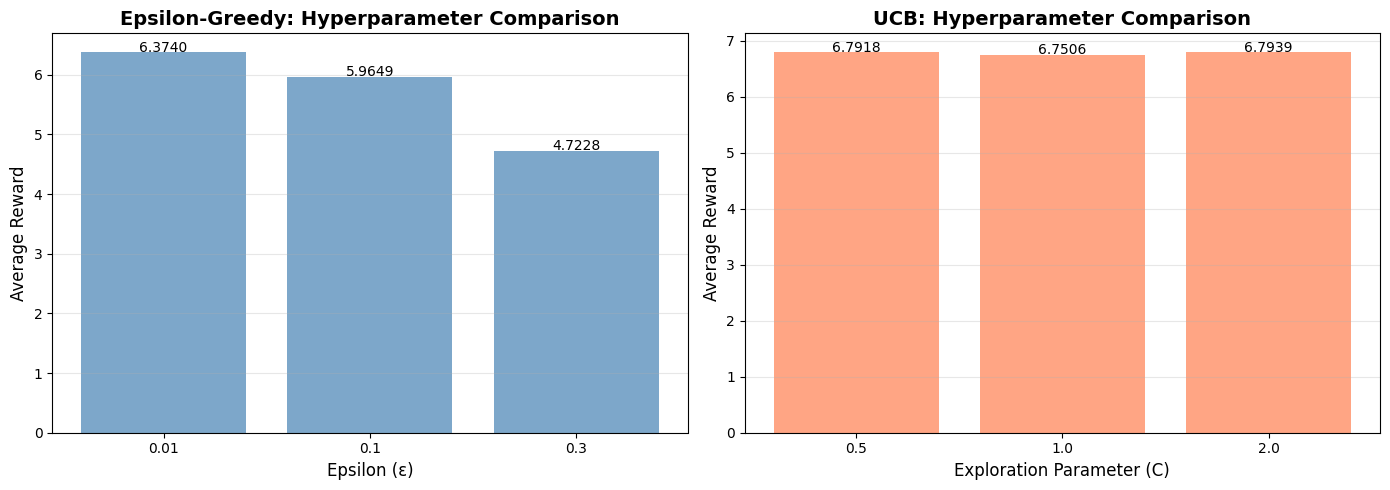

In [15]:
# Hyperparameter Comparison - Bar Charts

# Epsilon-Greedy: Final Average Rewards for different epsilon values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eps_avg_rewards = [np.mean(eg_results[eps]['rewards']) for eps in epsilon_values]
axes[0].bar([str(eps) for eps in epsilon_values], eps_avg_rewards, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Epsilon (ε)', fontsize=12)
axes[0].set_ylabel('Average Reward', fontsize=12)
axes[0].set_title('Epsilon-Greedy: Hyperparameter Comparison', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(eps_avg_rewards):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# UCB: Final Average Rewards for different C values
c_avg_rewards = [np.mean(ucb_results[c]['rewards']) for c in c_values]
axes[1].bar([str(c) for c in c_values], c_avg_rewards, color='coral', alpha=0.7)
axes[1].set_xlabel('Exploration Parameter (C)', fontsize=12)
axes[1].set_ylabel('Average Reward', fontsize=12)
axes[1].set_title('UCB: Hyperparameter Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(c_avg_rewards):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Average Reward per Context - Epsilon-Greedy


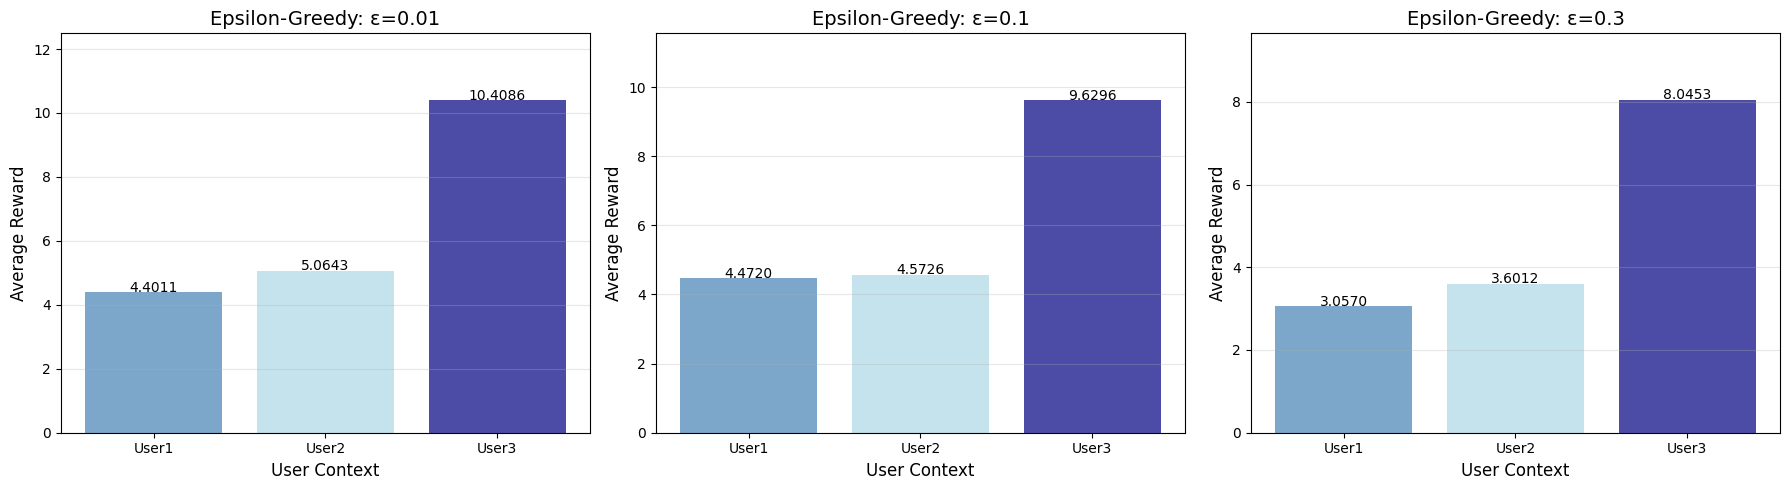

Average Reward per Context - UCB


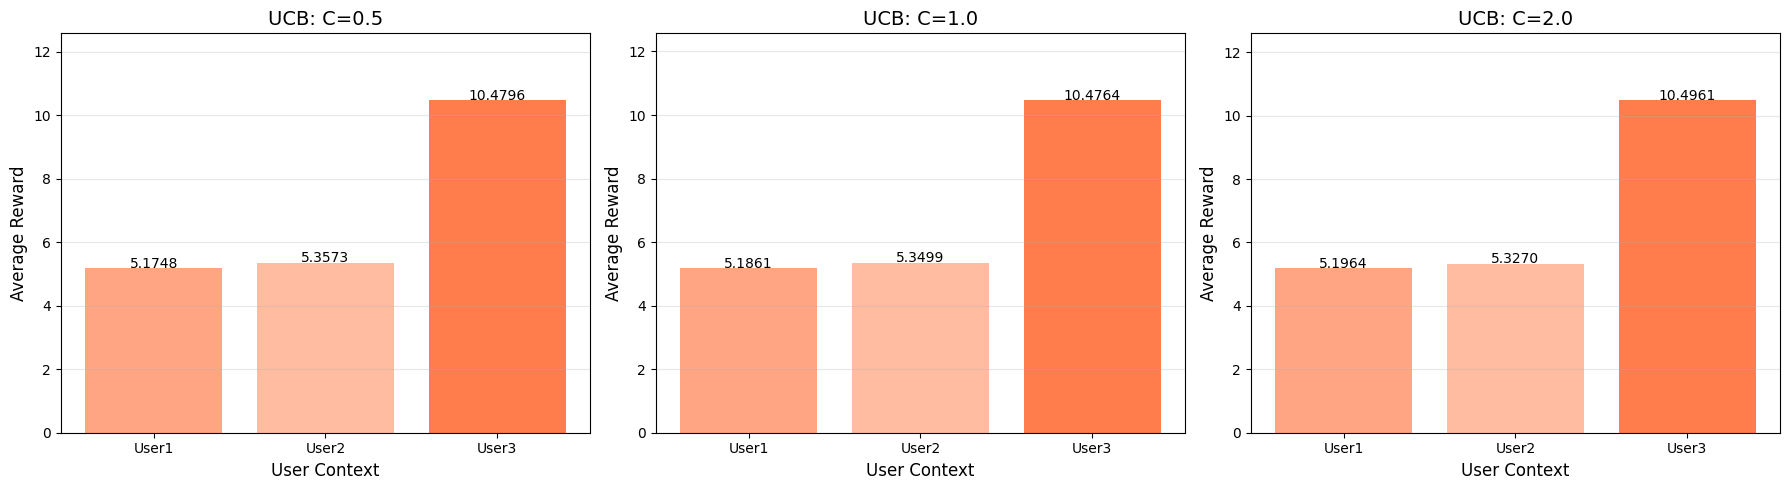

In [16]:
# Average Reward per Context - Analysis

def plot_context_rewards(results_dict, title, colors):
    """Plot average rewards per context for different hyperparameters"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (param_val, result) in enumerate(results_dict.items()):
        context_avgs = []
        for context in range(3):
            if len(result['context_rewards'][context]) > 0:
                context_avgs.append(np.mean(result['context_rewards'][context]))
            else:
                context_avgs.append(0)
        
        axes[idx].bar(['User1', 'User2', 'User3'], context_avgs, color=colors, alpha=0.7)
        axes[idx].set_xlabel('User Context', fontsize=12)
        axes[idx].set_ylabel('Average Reward', fontsize=12)
        axes[idx].set_title(f'{title}: {param_val}', fontsize=14)
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].set_ylim([0, max(context_avgs) * 1.2])
        
        # Add value labels
        for i, v in enumerate(context_avgs):
            axes[idx].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Plot for Epsilon-Greedy
print("Average Reward per Context - Epsilon-Greedy")
plot_context_rewards({f'ε={eps}': eg_results[eps] for eps in epsilon_values}, 
                     'Epsilon-Greedy', ['steelblue', 'lightblue', 'navy'])

# Plot for UCB
print("Average Reward per Context - UCB")
plot_context_rewards({f'C={c}': ucb_results[c] for c in c_values}, 
                     'UCB', ['coral', 'lightsalmon', 'orangered'])

In [17]:
# Display Expected Reward Distribution (Q-values)

print("\n" + "="*70)
print("EXPECTED REWARD DISTRIBUTION (Q-VALUES)")
print("="*70)

# Epsilon-Greedy Q-values
print("\n--- Epsilon-Greedy (ε=0.1) ---")
print("Q-values (Context x Category):")
print(f"{'':12} Entertainment  Education     Tech        Crime")
for i, user in enumerate(['User1', 'User2', 'User3']):
    print(f"{user:12} {eg_results[0.1]['Q'][i][0]:10.4f}  {eg_results[0.1]['Q'][i][1]:10.4f}  {eg_results[0.1]['Q'][i][2]:10.4f}  {eg_results[0.1]['Q'][i][3]:10.4f}")

print("\nPull counts (N):")
print(f"{'':12} Entertainment  Education     Tech        Crime")
for i, user in enumerate(['User1', 'User2', 'User3']):
    print(f"{user:12} {eg_results[0.1]['N'][i][0]:10.0f}  {eg_results[0.1]['N'][i][1]:10.0f}  {eg_results[0.1]['N'][i][2]:10.0f}  {eg_results[0.1]['N'][i][3]:10.0f}")

# UCB Q-values
print("\n--- UCB (C=1.0) ---")
print("Q-values (Context x Category):")
print(f"{'':12} Entertainment  Education     Tech        Crime")
for i, user in enumerate(['User1', 'User2', 'User3']):
    print(f"{user:12} {ucb_results[1.0]['Q'][i][0]:10.4f}  {ucb_results[1.0]['Q'][i][1]:10.4f}  {ucb_results[1.0]['Q'][i][2]:10.4f}  {ucb_results[1.0]['Q'][i][3]:10.4f}")

print("\nPull counts (N):")
print(f"{'':12} Entertainment  Education     Tech        Crime")
for i, user in enumerate(['User1', 'User2', 'User3']):
    print(f"{user:12} {ucb_results[1.0]['N'][i][0]:10.0f}  {ucb_results[1.0]['N'][i][1]:10.0f}  {ucb_results[1.0]['N'][i][2]:10.0f}  {ucb_results[1.0]['N'][i][3]:10.0f}")

# SoftMax Q-values
print("\n--- SoftMax (τ=1.0) ---")
print("Q-values (Context x Category):")
print(f"{'':12} Entertainment  Education     Tech        Crime")
for i, user in enumerate(['User1', 'User2', 'User3']):
    print(f"{user:12} {sm_results['Q'][i][0]:10.4f}  {sm_results['Q'][i][1]:10.4f}  {sm_results['Q'][i][2]:10.4f}  {sm_results['Q'][i][3]:10.4f}")

print("\nPull counts (N):")
print(f"{'':12} Entertainment  Education     Tech        Crime")
for i, user in enumerate(['User1', 'User2', 'User3']):
    print(f"{user:12} {sm_results['N'][i][0]:10.0f}  {sm_results['N'][i][1]:10.0f}  {sm_results['N'][i][2]:10.0f}  {sm_results['N'][i][3]:10.0f}")

print("\n" + "="*70)


EXPECTED REWARD DISTRIBUTION (Q-VALUES)

--- Epsilon-Greedy (ε=0.1) ---
Q-values (Context x Category):
             Entertainment  Education     Tech        Crime
User1            0.1744     -9.5918      5.2046     -4.0206
User2            1.6006     -5.6099     -4.1982      5.3543
User3            0.5012     -3.5820      1.5481     10.5224

Pull counts (N):
             Entertainment  Education     Tech        Crime
User1                88         100        3340          78
User2               200          98         101        3170
User3                65          69         100        2591

--- UCB (C=1.0) ---
Q-values (Context x Category):
             Entertainment  Education     Tech        Crime
User1           -0.9666    -10.1225      5.1947     -4.4753
User2            1.7089     -6.9920     -4.9912      5.3584
User3           -0.0314     -2.6157      1.8157     10.4877

Pull counts (N):
             Entertainment  Education     Tech        Crime
User1                 1     

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


In [18]:
# Final Observations Summary

print("\n" + "="*70)
print("FINAL OBSERVATIONS")
print("="*70)

# Calculate final metrics
eg_final_rewards = {eps: np.mean(eg_results[eps]['rewards']) for eps in epsilon_values}
ucb_final_rewards = {c: np.mean(ucb_results[c]['rewards']) for c in c_values}
sm_final_reward = np.mean(sm_results['rewards'])

print("\n1. ALGORITHM PERFORMANCE SUMMARY")
print("-" * 70)
print(f"Epsilon-Greedy:")
for eps in epsilon_values:
    print(f"  ε={eps}: Average Reward = {eg_final_rewards[eps]:.4f}")

print(f"\nUCB:")
for c in c_values:
    print(f"  C={c}: Average Reward = {ucb_final_rewards[c]:.4f}")

print(f"\nSoftMax:")
print(f"  τ={tau}: Average Reward = {sm_final_reward:.4f}")

# Find best performing algorithms
best_eg = max(eg_final_rewards, key=eg_final_rewards.get)
best_ucb = max(ucb_final_rewards, key=ucb_final_rewards.get)

print("\n2. BEST HYPERPARAMETERS")
print("-" * 70)
print(f"Best Epsilon-Greedy: ε={best_eg} (Avg Reward: {eg_final_rewards[best_eg]:.4f})")
print(f"Best UCB: C={best_ucb} (Avg Reward: {ucb_final_rewards[best_ucb]:.4f})")
print(f"SoftMax: τ={tau} (Avg Reward: {sm_final_reward:.4f})")

# Overall best algorithm
all_performances = {
    f'Epsilon-Greedy (ε={best_eg})': eg_final_rewards[best_eg],
    f'UCB (C={best_ucb})': ucb_final_rewards[best_ucb],
    f'SoftMax (τ={tau})': sm_final_reward
}
best_algorithm = max(all_performances, key=all_performances.get)

print("\n3. OVERALL BEST ALGORITHM")
print("-" * 70)
print(f"{best_algorithm}: {all_performances[best_algorithm]:.4f}")

print("\n4. KEY INSIGHTS")
print("-" * 70)
print("• Epsilon-Greedy: Balance between exploration and exploitation")
print("  - Lower ε (0.01) focuses more on exploitation")
print("  - Higher ε (0.3) explores more, may sacrifice short-term rewards")
print("\n• UCB: Optimistic exploration based on uncertainty")
print("  - Lower C values focus on exploitation")
print("  - Higher C values encourage more exploration")
print("\n• SoftMax: Probabilistic selection based on Q-values")
print("  - Temperature τ=1 provides moderate exploration")
print("  - Smooth transition between exploration and exploitation")

print("\n5. CONTEXTUAL LEARNING")
print("-" * 70)
print("• Each algorithm learned different preferences for different user contexts")
print("• The Q-values show which news categories work best for each user type")
print("• Contextual information significantly improves recommendation quality")

print("\n" + "="*70)


FINAL OBSERVATIONS

1. ALGORITHM PERFORMANCE SUMMARY
----------------------------------------------------------------------
Epsilon-Greedy:
  ε=0.01: Average Reward = 6.3740
  ε=0.1: Average Reward = 5.9649
  ε=0.3: Average Reward = 4.7228

UCB:
  C=0.5: Average Reward = 6.7918
  C=1.0: Average Reward = 6.7506
  C=2.0: Average Reward = 6.7939

SoftMax:
  τ=1.0: Average Reward = 6.7551

2. BEST HYPERPARAMETERS
----------------------------------------------------------------------
Best Epsilon-Greedy: ε=0.01 (Avg Reward: 6.3740)
Best UCB: C=2.0 (Avg Reward: 6.7939)
SoftMax: τ=1.0 (Avg Reward: 6.7551)

3. OVERALL BEST ALGORITHM
----------------------------------------------------------------------
UCB (C=2.0): 6.7939

4. KEY INSIGHTS
----------------------------------------------------------------------
• Epsilon-Greedy: Balance between exploration and exploitation
  - Lower ε (0.01) focuses more on exploitation
  - Higher ε (0.3) explores more, may sacrifice short-term rewards

• UCB: O

# Recommendation Engine

This section implements the end-to-end recommendation system that:
1. Takes user features from `test_users.csv`
2. Classifies the user into User1/User2/User3
3. Selects optimal news category using the trained bandit policy
4. Recommends a specific article from that category

In [19]:
# Recommendation Engine Implementation

class NewsRecommendationEngine:
    def __init__(self, user_classifier, bandit, news_df, label_encoder):
        self.user_classifier = user_classifier
        self.bandit = bandit
        self.news_df = news_df
        self.label_encoder = label_encoder
        self.categories_map = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
        
    def recommend(self, user_features):
        """
        End-to-end recommendation for a user
        Returns: (predicted_user_type, recommended_category, article)
        """
        # Step 1: Classify user
        user_context_encoded = self.user_classifier.predict([user_features])[0]
        user_context = self.label_encoder.inverse_transform([user_context_encoded])[0]
        
        # Step 2: Select optimal news category using bandit
        # Get the best arm for this context (greedy selection from learned Q-values)
        best_arm = np.argmax(self.bandit.Q[user_context_encoded])
        recommended_category = self.categories_map[best_arm]
        
        # Step 3: Sample a random article from the selected category
        category_articles = self.news_df[self.news_df['category'] == recommended_category]
        
        if len(category_articles) > 0:
            article = category_articles.sample(n=1).iloc[0]
        else:
            # Fallback if category not found
            article = self.news_df.sample(n=1).iloc[0]
            
        return user_context, recommended_category, article

# Initialize recommendation engine with best performing bandit (use Epsilon-Greedy with ε=0.1)
rec_engine = NewsRecommendationEngine(
    user_classifier=user_classifier,
    bandit=eg_bandit,  # Using the last trained epsilon-greedy bandit
    news_df=news_df,
    label_encoder=le_label
)

print("Recommendation Engine initialized successfully!")

Recommendation Engine initialized successfully!


In [20]:
# Generate predictions for test users

print("Generating recommendations for test users...\n")

# Prepare test data
X_test_features = test_users_clean[feature_cols].values

# Create a list to store recommendations
recommendations = []

# Generate recommendations for first 10 test users (as examples)
for i in range(min(10, len(test_users_clean))):
    user_id = test_users_clean.iloc[i]['user_id']
    user_features = X_test_features[i]
    
    user_context, recommended_category, article = rec_engine.recommend(user_features)
    
    recommendations.append({
        'user_id': user_id,
        'predicted_context': user_context,
        'recommended_category': recommended_category,
        'article_headline': article['headline'],
        'article_link': article['link']
    })
    
    print(f"User {user_id} ({user_context}):")
    print(f"  Recommended: {recommended_category}")
    print(f"  Article: {article['headline'][:80]}...")
    print()

# Create DataFrame of recommendations
recommendations_df = pd.DataFrame(recommendations)
print(f"\nGenerated {len(recommendations)} recommendations")
print("\nRecommendations Summary:")
print(recommendations_df[['user_id', 'predicted_context', 'recommended_category']].head())

Generating recommendations for test users...

User U4058 (user_2):
  Recommended: CRIME
  Article: Bungling Bicycle-Riding Robbery Suspect Is Foiled By Wet Weather...

User U1118 (user_1):
  Recommended: TECH
  Article: Facebook's New Mission: A Global Community...

User U6555 (user_1):
  Recommended: TECH
  Article: German Watchdog Threatens To Use 'Instruments Of Torture' Against Amazon...

User U9170 (user_1):
  Recommended: TECH
  Article: A Bright Spot in the Dark Side of Technology...

User U3348 (user_1):
  Recommended: TECH
  Article: Cyber Monday 2015 May Set A New Record...

User U2244 (user_3):
  Recommended: CRIME
  Article: Baby Boy Dies After Being Left In Hot Car For 40 Minutes...

User U3022 (user_3):
  Recommended: CRIME
  Article: Oakland Fire Is Deadliest In U.S. Since 2003...

User U5291 (user_1):
  Recommended: TECH
  Article: Apple, HTC Lawsuit Settled By Agreeing Not To Fight For 1 Whole Decade...

User U1945 (user_3):
  Recommended: CRIME
  Article: Photo Booth 

/Users/swaruplaxmikant/Desktop/lab3-contextual-bandit-master/.venv313/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/swaruplaxmikant/Desktop/lab3-contextual-bandit-master/.venv313/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/swaruplaxmikant/Desktop/lab3-contextual-bandit-master/.venv313/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/swaruplaxmikant/Desktop/lab3-contextual-bandit-master/.venv313/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with fea

In [21]:
# Save predictions to CSV file

# Generate predictions for all test users
all_recommendations = []

for i in range(len(test_users_clean)):
    user_id = test_users_clean.iloc[i]['user_id']
    user_features = X_test_features[i]
    
    user_context, recommended_category, article = rec_engine.recommend(user_features)
    
    all_recommendations.append({
        'user_id': user_id,
        'predicted_user_category': user_context,
        'recommended_news_category': recommended_category
    })

# Create DataFrame and save to CSV
predictions_df = pd.DataFrame(all_recommendations)
predictions_df.to_csv('test_user_predictions.csv', index=False)

print(f"✓ Saved predictions for {len(predictions_df)} test users to 'test_user_predictions.csv'")
print(f"\nPredictions distribution:")
print(predictions_df['recommended_news_category'].value_counts())
print(f"\nUser category distribution:")
print(predictions_df['predicted_user_category'].value_counts())

/Users/swaruplaxmikant/Desktop/lab3-contextual-bandit-master/.venv313/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/swaruplaxmikant/Desktop/lab3-contextual-bandit-master/.venv313/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/swaruplaxmikant/Desktop/lab3-contextual-bandit-master/.venv313/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/swaruplaxmikant/Desktop/lab3-contextual-bandit-master/.venv313/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with fea

✓ Saved predictions for 2000 test users to 'test_user_predictions.csv'

Predictions distribution:
recommended_news_category
CRIME    1326
TECH      674
Name: count, dtype: int64

User category distribution:
predicted_user_category
user_2    694
user_1    674
user_3    632
Name: count, dtype: int64


/Users/swaruplaxmikant/Desktop/lab3-contextual-bandit-master/.venv313/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
